# Toy Dependency Without Conditional Independence

This notebook studies a toy dataset in which the third variable depends jointly on the first two.

More precisely, the data are generated from a noisy multiplicative interaction,
$$c = x y + \varepsilon,$$
so the dependence structure is fundamentally different from the conditional-independence example in the previous notebook.

The key point is that this relationship cannot be represented faithfully by a simple two-factor decomposition of the form used before. From the viewpoint of the Bethe approximation, once the factor graph contains cycles, the factorization is no longer exact and only provides an approximation. In this setting, that approximation is not strong enough to recover the conditional behavior reliably.

 >**Conditioning on $c$ with the factorized construction does not work well here. This is consistent with theory: because the information in $c$ depends jointly on both $x$ and $y$, it cannot be transmitted correctly through a decomposition that only models lower-order pairwise factors.**


In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from acg import get_sigmas_karras, sample_heun, ExactDenoiser
from acg.datasets import make_two_moons, make_gaussian_mixture

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Create target distribution

In [7]:

# --------------------------
# 1) Generate dataset
# --------------------------
def make_dataset(n=2000, seed=0):
    rng = np.random.default_rng(seed)

    x = rng.uniform(-1, 1, size=n)
    y = rng.uniform(-1, 1, size=n)
    c = x * y + 0.05 * rng.standard_normal(size=n)

    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    c = torch.tensor(z, dtype=torch.float32)

    return x, y, c


N = 20000
x, y, c = make_dataset(n=N)

print("Shapes:", x.shape, y.shape, c.shape)

Shapes: torch.Size([20000]) torch.Size([20000]) torch.Size([20000])


/tmp/ipykernel_32538/1006366276.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c = torch.tensor(z, dtype=torch.float32)


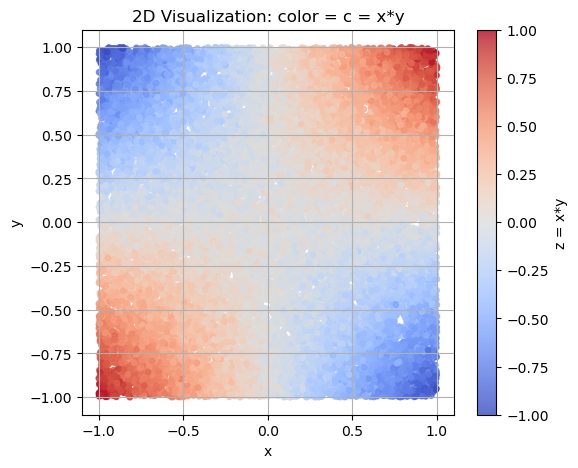

In [8]:

plt.figure(figsize=(6, 5))

sc = plt.scatter(
    x, y,
    c=c,
    cmap="coolwarm",
    vmin=-1.0,   # important: fix range
    vmax=1.0,
    s=15,
    alpha=0.8
)

plt.colorbar(sc, label="z = x*y")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Visualization: color = c = x*y")
plt.grid(True)

plt.show()

In [9]:
# Append color and coords
data = torch.stack([x, y, c], dim=1)

# shape: (N, 3) → (x, y, c)

## 2. Unconditional generation

### 2.1 Initial data

### 2.2  Denoiser

In [10]:
# Create Conditional Exact Denoiser
denoiser = ExactDenoiser(data=data)

print(f"Conditional denoiser created")
print(f"  - Data points: {denoiser.n_points}")

Conditional denoiser created
  - Data points: 20000


In [14]:
# Karras noise schedule
n_steps = 50
sigma_min = 0.01
sigma_max = 2.0

sigmas = get_sigmas_karras(
    n_steps=n_steps,
    sigma_min=sigma_min,
    sigma_max=sigma_max,
    device=device
)

# Scale initial samples
n_samples = 500
latents = torch.randn(n_samples, 3, device=device) * sigmas[0]

print(f"Noise schedule: {n_steps} steps, sigma=[{sigma_min}, {sigma_max}]")

Noise schedule: 50 steps, sigma=[0.01, 2.0]


In [15]:
# Sampling 

# Generate final samples and trajectories
traj= sample_heun(
    denoiser=denoiser,
    latents=latents.clone(),
    sigmas=sigmas,
    return_trajectory=True
)


print(f"Generated trajectories: {traj.shape}")

Generated trajectories: torch.Size([500, 51, 3])


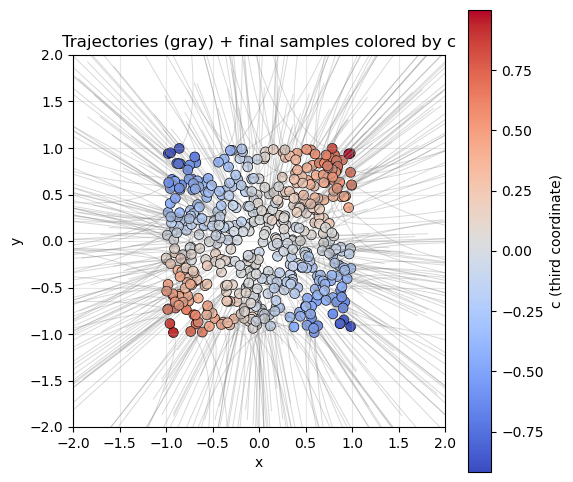

In [16]:


traj_np = traj.cpu().numpy()  # (N, T, 3)

plt.figure(figsize=(6, 6))

# 1. Plot trajectories in gray (only x,y)
for i in range(traj_np.shape[0]):
    plt.plot(
        traj_np[i, :, 0],   # x
        traj_np[i, :, 1],   # y
        color='gray',
        alpha=0.3,
        linewidth=0.7
    )

# 2. Final samples colored by c
sc = plt.scatter(
    traj_np[:, -1, 0],     # x_T
    traj_np[:, -1, 1],     # y_T
    c=traj_np[:, -1, 2],   # c_T → heatmap
    cmap='coolwarm',
    s=50,
    edgecolors='black',
    linewidth=0.5
)

# Colorbar
plt.colorbar(sc, label="c (third coordinate)")

plt.title("Trajectories (gray) + final samples colored by c")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')

plt.show()

### 3. Factor decomposition

- For x,y coordinates and color, c
- Approximation (not real prob):

$$\log p(x,y,c) \approx \log p(x,y) + \log p(y,c) + \log p(x,c) - \log p(x) - \log p(y) - \log p(c)$$

In [18]:
# Pair datasets
data_xy = data[:, [0, 1]]  # (x, y)
data_xc = data[:, [0, 2]]  # (x, y)
data_yc = data[:, [1, 2]]  # (y, c)
data_x  = data[:, [0]]     # y only
data_y  = data[:, [1]]     # y only
data_c  = data[:, [2]]     # y only

In [19]:
# Create denoisers for each 
denoiser_xy = ExactDenoiser(data=data_xy)
denoiser_yc = ExactDenoiser(data=data_yc)
denoiser_xc = ExactDenoiser(data=data_xc)
denoiser_x = ExactDenoiser(data=data_x)
denoiser_y = ExactDenoiser(data=data_y)
denoiser_c = ExactDenoiser(data=data_c)

print(f"Conditional denoisers created")

# Can use same noise schedule and latents as before

Conditional denoisers created


In [20]:
class FactorGraphDenoiser:
    def __init__(
        self,
        denoiser_xy,
        denoiser_yc,
        denoiser_xc,
        denoiser_x,
        denoiser_y,
        denoiser_c,
    ):
        self.denoiser_xy = denoiser_xy
        self.denoiser_yc = denoiser_yc
        self.denoiser_xc = denoiser_xc
        self.denoiser_x = denoiser_x
        self.denoiser_y = denoiser_y
        self.denoiser_c = denoiser_c

    def __call__(self, x_full: torch.Tensor, sigma: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        x_full: [B, 3] = [x, y, c]
        sigma: scalar tensor or [B]
        returns: [B, 3] full denoised prediction
        """
        # Make sigma broadcastable to [B, 1]
        if sigma.ndim == 0:
            sigma_sq = sigma**2
        else:
            sigma_sq = sigma.view(-1, 1) ** 2

        # Split variables as column vectors
        x = x_full[:, 0:1]   # [B,1]
        y = x_full[:, 1:2]   # [B,1]
        c = x_full[:, 2:3]   # [B,1]

        # Build factor inputs
        xy = torch.cat([x, y], dim=1)   # [B,2]
        yc = torch.cat([y, c], dim=1)   # [B,2]
        xc = torch.cat([x, c], dim=1)   # [B,2]

        # Local denoisers
        D_xy = self.denoiser_xy(xy, sigma)   # [B,2]
        D_yc = self.denoiser_yc(yc, sigma)   # [B,2]
        D_xc = self.denoiser_xc(xc, sigma)   # [B,2]

        D_x = self.denoiser_x(x, sigma)      # [B,1]
        D_y = self.denoiser_y(y, sigma)      # [B,1]
        D_c = self.denoiser_c(c, sigma)      # [B,1]

        # Convert local denoisers -> local scores
        s_xy = (D_xy - xy) / sigma_sq   # [B,2]
        s_yc = (D_yc - yc) / sigma_sq   # [B,2]
        s_xc = (D_xc - xc) / sigma_sq   # [B,2]

        s_x = (D_x - x) / sigma_sq      # [B,1]
        s_y = (D_y - y) / sigma_sq      # [B,1]
        s_c = (D_c - c) / sigma_sq      # [B,1]

        # Combine into full 3D score
        s_full = torch.zeros_like(x_full)   # [B,3]

        # x gets contributions from xy and xc, minus singleton x
        s_full[:, 0:1] = s_xy[:, 0:1] + s_xc[:, 0:1] - s_x

        # y gets contributions from xy and yc, minus singleton y
        s_full[:, 1:2] = s_xy[:, 1:2] + s_yc[:, 0:1] - s_y

        # c gets contributions from yc and xc, minus singleton c
        s_full[:, 2:3] = s_yc[:, 1:2] + s_xc[:, 1:2] - s_c

        # Convert combined score -> full denoiser
        D_full = x_full + sigma_sq * s_full
        return D_full

In [21]:
# Wrap them
factor_denoiser = FactorGraphDenoiser(
    denoiser_xy=denoiser_xy,
    denoiser_yc=denoiser_yc,
    denoiser_xc=denoiser_xc,
    denoiser_x=denoiser_x,
    denoiser_y=denoiser_y,
    denoiser_c=denoiser_c,
)

# Sample
traj = sample_heun(
    denoiser=factor_denoiser,
    latents=latents.clone(),   # [B,2]
    sigmas=sigmas,
    return_trajectory=True
)

print(traj.shape)

torch.Size([500, 51, 3])


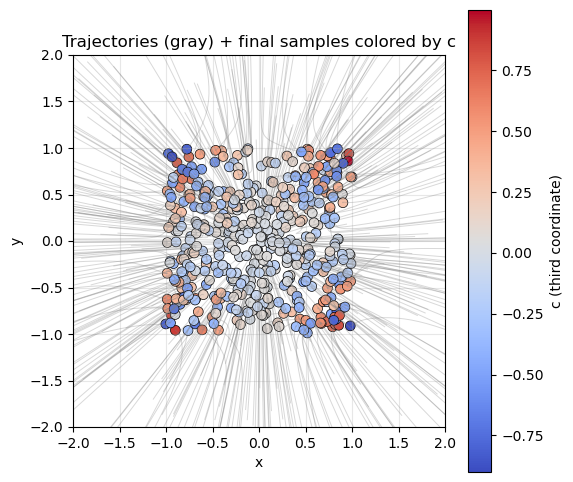

In [22]:


traj_np = traj.cpu().numpy()  # (N, T, 3)

plt.figure(figsize=(6, 6))

# 1. Plot trajectories in gray (only x,y)
for i in range(traj_np.shape[0]):
    plt.plot(
        traj_np[i, :, 0],   # x
        traj_np[i, :, 1],   # y
        color='gray',
        alpha=0.3,
        linewidth=0.7
    )

# 2. Final samples colored by c
sc = plt.scatter(
    traj_np[:, -1, 0],     # x_T
    traj_np[:, -1, 1],     # y_T
    c=traj_np[:, -1, 2],   # c_T → heatmap
    cmap='coolwarm',
    s=50,
    edgecolors='black',
    linewidth=0.5
)

# Colorbar
plt.colorbar(sc, label="c (third coordinate)")

plt.title("Trajectories (gray) + final samples colored by c")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')

plt.show()

In [23]:
samples = traj[:, -1, :].cpu()
xg = samples[:, 0]
yg = samples[:, 1]
cg = samples[:, 2]

residual = cg - xg * yg
print("mean |c - x*y|:", residual.abs().mean().item())
print("std(c - x*y):", residual.std().item())

mean |c - x*y|: 0.27652886509895325
std(c - x*y): 0.4487736225128174


In [24]:
residual_true = c - x * y
print("true mean |c - x*y|:", residual_true.abs().mean().item())
print("true std(c - x*y):", residual_true.std().item())

true mean |c - x*y|: 0.03980034962296486
true std(c - x*y): 0.04991452395915985


### 4. Factor decomposition conditioned on c

In [ ]:

class FactorGraphDenoiserCondC:
    def __init__(self, denoiser_xy, denoiser_yc, denoiser_y, c_fixed, guidance_scale):
        self.denoiser_xy = denoiser_xy
        self.denoiser_yc = denoiser_yc
        self.denoiser_y = denoiser_y
        self.c_fixed = c_fixed
        self.guidance_scale = guidance_scale

    def __call__(self, x_full: torch.Tensor, sigma: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        x_full: [B, 2] = [x, y]
        sigma: scalar tensor or [B] / [1]
        returns: [B, 2] full denoised prediction
        """
        B = x_full.shape[0]

        # Make sigma broadcastable to [B, 1]
        if sigma.ndim == 0:
            sigma_sq = sigma**2
        else:
            sigma_sq = sigma.view(-1, 1) ** 2

        # Split variables
        x = x_full[:, 0:1]   # [B,1]
        y = x_full[:, 1:2]   # [B,1]

        c = torch.full_like(y, self.c_fixed)
    

        # Build factor inputs
        xy = torch.cat([x, y], dim=1)   # [B,2]
        yc = torch.cat([y, c], dim=1)   # [B,2]

        # Local denoisers
        D_xy = self.denoiser_xy(xy, sigma)   # [B,2]
        D_yc = self.denoiser_yc(yc, sigma)   # [B,2]
        D_y  = self.denoiser_y(y, sigma)     # [B,1]

        # Convert local denoisers -> local scores
        s_xy = (D_xy - xy) / sigma_sq        # [B,2]
        s_yc = (D_yc - yc) / sigma_sq        # [B,2]
        s_y  = (D_y  - y)  / sigma_sq        # [B,1]

        # Combine into full 3D score
        s_full = torch.zeros_like(x_full)    # [B,3]
        s_full[:, 0:1] = s_xy[:, 0:1]                        # x contribution

        # CFG scaling
        s_full[:, 1:2] = s_xy[:, 1:2] +  self.guidance_scale * (s_yc[:, 0:1] - s_y) # y contribution                    # c contribution

        # Convert combined score -> full denoiser
        D_full = x_full + sigma_sq * s_full
        return D_full

In [143]:
# Fixed value for c
C = 1.0

# Pair datasets
data_xy = data[:, [0, 1]]  # (x, y)
data_yc = data[:, [1, 2]]  # (y, c)
data_y  = data[:, [1]]     # y only

# Create denoisers for each 
denoiser_xy = ExactDenoiser(data=data_xy)
denoiser_yc = ExactDenoiser(data=data_yc)
denoiser_y = ExactDenoiser(data=data_y)

print(f"Conditional denoisers created")

# Noise schedule
# Karras noise schedule
n_steps = 100
sigma_min = 0.01
sigma_max = 2.0

sigmas = get_sigmas_karras(
    n_steps=n_steps,
    sigma_min=sigma_min,
    sigma_max=sigma_max,
    device=device
)

# Scale initial samples
n_samples = 20
latents = torch.randn(n_samples, 2, device=device) * sigmas[0]

print(f"Noise schedule: {n_steps} steps, sigma=[{sigma_min}, {sigma_max}]")

# Wrap them
factor_denoiser = FactorGraphDenoiserCondC(
    denoiser_xy=denoiser_xy,
    denoiser_yc=denoiser_yc,
    denoiser_y=denoiser_y,
    c_fixed = C,
    guidance_scale=10
)

# Sample
traj = sample_heun(
    denoiser=factor_denoiser,
    latents=latents.clone(),   # [B,2]
    sigmas=sigmas,
    return_trajectory=True
)

print(traj.shape)

# Add c
traj = torch.cat([traj, torch.full_like(traj[..., :1], C)], dim=2)

Conditional denoisers created
Noise schedule: 100 steps, sigma=[0.01, 2.0]
torch.Size([20, 101, 2])


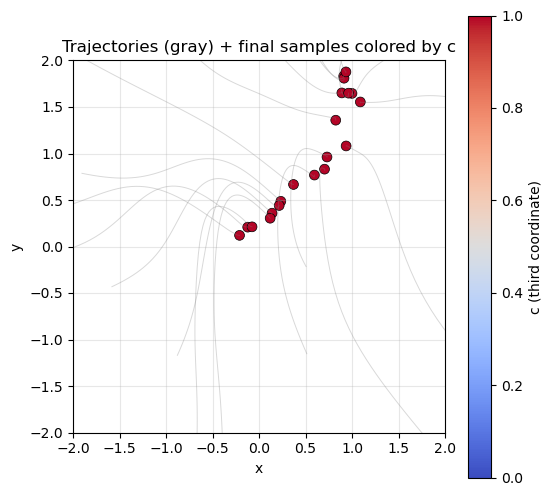

In [144]:


traj_np = traj.cpu().numpy()  # (N, T, 3)

plt.figure(figsize=(6, 6))

# 1. Plot trajectories in gray (only x,y)
for i in range(traj_np.shape[0]):
    plt.plot(
        traj_np[i, :, 0],   # x
        traj_np[i, :, 1],   # y
        color='gray',
        alpha=0.3,
        linewidth=0.7
    )

# 2. Final samples colored by c
sc = plt.scatter(
    traj_np[:, -1, 0],
    traj_np[:, -1, 1],
    c=traj_np[:, -1, 2],
    cmap='coolwarm',
    vmin=0.0,   #  Force full scale
    vmax=1.0,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

# Colorbar
plt.colorbar(sc, label="c (third coordinate)")

plt.title("Trajectories (gray) + final samples colored by c")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')

plt.show()